In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/ltv_dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,29.85,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,42.30,1840.75,No,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,70.70,151.65,Yes,141.40


In [3]:
#Prepare Features and Target
X = df.drop(columns=["LTV"])

X = X.drop(columns=["customerID"])

y = df["LTV"]

#Check shapes:

print(X.shape)
print(y.shape)

(7032, 11)
(7032,)


In [4]:
#Load the model selected in Days 11–12.

model = joblib.load("../models/ltv_model.pkl")

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [5]:
#Generate Predictions
predictions = model.predict(X)

#Preview predictions:

predictions[:10]

array([  31.926907, 1917.1305  ,  106.101456, 1818.5273  ,  154.8394  ,
        819.38403 , 1935.6841  ,  299.20624 , 3027.5093  , 3511.5     ],
      dtype=float32)

In [6]:
#Create a Comparison Table
comparison = pd.DataFrame({
    "Actual_LTV": y,
    "Predicted_LTV": predictions
})

comparison.head(10)

,Actual_LTV,Predicted_LTV
0,29.85,31.926907
1,1936.30,1917.130493
2,107.70,106.101456
3,1903.50,1818.527344
4,141.40,154.839401
5,797.20,819.384033
6,1960.20,1935.684082
7,297.50,299.206238
8,2934.40,3027.509277
9,3481.30,3511.500000


In [7]:
#Calculate Validation Metrics
#Mean Absolute Error (MAE)
mae = mean_absolute_error(y, predictions)

print("MAE:", mae)
#Mean Squared Error (MSE)
mse = mean_squared_error(y, predictions)

print("MSE:", mse)
#Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
#R² Score
r2 = r2_score(y, predictions)

print("R² Score:", r2)

MAE: 36.218516580290895
MSE: 2776.81816753387
RMSE: 52.69552322098975
R² Score: 0.9994585148258694


In [8]:
#Create a Metrics Summary
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,36.218517
1,MSE,2776.818168
2,RMSE,52.695523
3,R² Score,0.999459


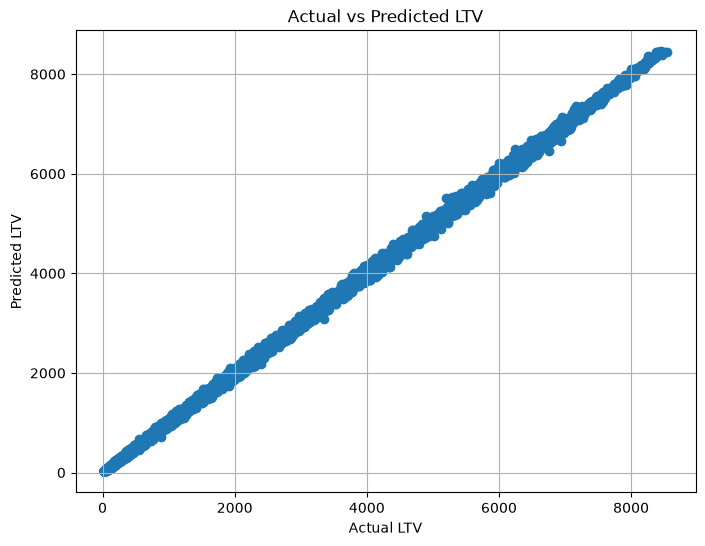

In [9]:
#Plot Actual vs Predicted LTV
plt.figure(figsize=(8,6))

plt.scatter(y, predictions)

plt.xlabel("Actual LTV")

plt.ylabel("Predicted LTV")

plt.title("Actual vs Predicted LTV")

plt.grid(True)

plt.show()

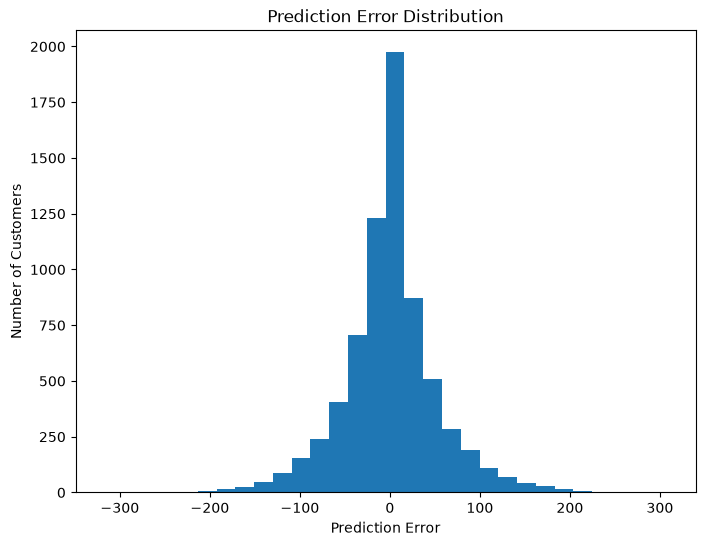

In [10]:
#Plot Prediction Errors
errors = y - predictions

plt.figure(figsize=(8,6))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")

plt.ylabel("Number of Customers")

plt.title("Prediction Error Distribution")

plt.show()

In [11]:
#Save Validation Results
comparison.to_csv(
    "../docs/ltv_prediction_validation.csv",
    index=False
)

In [ ]:
## Day 19 Conclusion

# The final LTV model was validated by comparing predicted LTV with actual LTV values.

# ### Evaluation Metrics

# - MAE
# - MSE
# - RMSE
# - R² Score

# ### Observations

# - The scatter plot shows how closely predictions match actual values.
# - The error distribution helps identify whether the model consistently overestimates or underestimates LTV.
# - These results confirm whether the selected model is suitable for predicting customer lifetime value.